In [27]:
pip install matplotlib


[notice] A new release of pip is available: 23.2.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [26]:
TRAIN_DIR = 'C:/Users/kinta/Downloads/Phyton/dataset/dataset/plant_dataset/train'
VALIDATION_DIR = 'C:/Users/kinta/Downloads/Phyton/dataset/dataset/plant_dataset/valid'

In [28]:
import os

# Define the directory path
train_dir = r'C:/Users/kinta/Downloads/Phyton/dataset/dataset/plant_dataset/train'

# Get all folders (directories) in the specified directory
folder_names = [folder for folder in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, folder))]

# Print the list of folder names
print(folder_names)


['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___healthy', 'Strawberry___Leaf_scorch', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___healthy', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite',

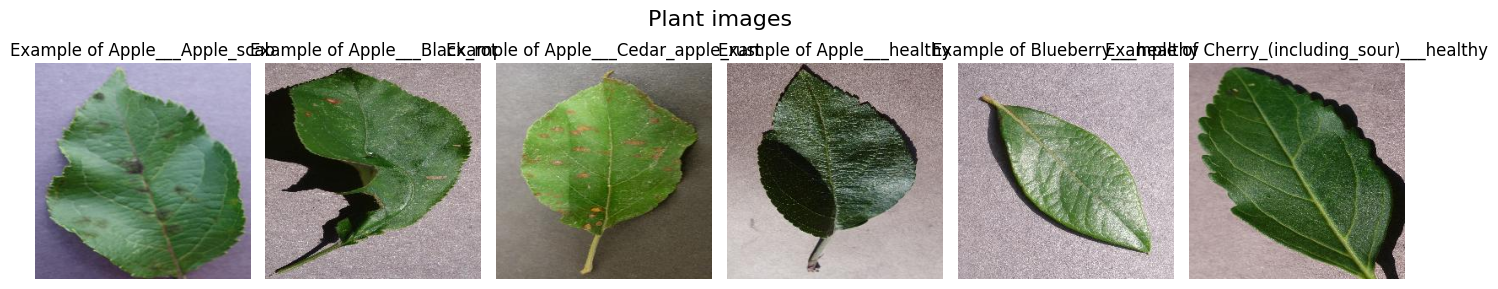

In [29]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

# Assuming 'folder_names' is already defined and contains the folder names
train_dir = r'C:/Users/kinta/Downloads/Phyton/dataset/dataset/plant_dataset/train'

# Set up the plot
fig, axes = plt.subplots(1, 6, figsize=(14, 3))
fig.suptitle('Plant images', fontsize=16)

# Plot one image from each of the first 6 folders in 'folder_names'
for ii, plant in enumerate(folder_names[:6]):  # Limit to the first 6 folders
    folder_path = os.path.join(train_dir, plant)
    
    # Get the first image in the folder
    img_path = os.path.join(folder_path, os.listdir(folder_path)[0])  # Get first image
    img = tf.keras.preprocessing.image.load_img(img_path)
    
    # Display the image
    axes[ii].imshow(img)
    axes[ii].set_title(f'Example of {plant}')
    axes[ii].axis('off')  # Optional: Hide axes for a cleaner plot

plt.tight_layout()
plt.show()


In [30]:
sample_array = tf.keras.preprocessing.image.img_to_array(img)

print(f"Each image has shape: {sample_array.shape}")

Each image has shape: (256, 256, 3)


In [31]:
sample_array[0,:5]

array([[165., 146., 148.],
       [165., 146., 148.],
       [164., 145., 147.],
       [164., 145., 147.],
       [164., 145., 147.]], dtype=float32)

In [32]:
def train_val_datasets():
    """Create train and validation datasets

    Returns:
        (tf.data.Dataset, tf.data.Dataset): train and validation datasets
    """
    ### START CODE HERE ###
    train_dataset = tf.keras.utils.image_dataset_from_directory( 
        directory=TRAIN_DIR,
        batch_size=32,
        image_size=(256,256),
        label_mode="int",
    ) 
    
    validation_dataset = tf.keras.utils.image_dataset_from_directory( 
        directory=VALIDATION_DIR,
        batch_size=32,
        image_size=(256,256),
        label_mode="int",
    ) 

    # Extract class names from the train dataset
    class_labels = {index: label for index, label in enumerate(train_dataset.class_names)}
    ### END CODE HERE ###
    
    return train_dataset, validation_dataset, class_labels  


In [33]:
train_dataset, validation_dataset,class_labels = train_val_datasets()
print(f"Images of train dataset have shape: {train_dataset.element_spec[0].shape}")
print(f"Labels of train dataset have shape: {train_dataset.element_spec[1].shape}")
print(f"Images of validation dataset have shape: {validation_dataset.element_spec[0].shape}")
print(f"Labels of validation dataset have shape: {validation_dataset.element_spec[1].shape}")   

Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.
Images of train dataset have shape: (None, 256, 256, 3)
Labels of train dataset have shape: (None,)
Images of validation dataset have shape: (None, 256, 256, 3)
Labels of validation dataset have shape: (None,)


In [34]:
print(class_labels)

{0: 'Apple___Apple_scab', 1: 'Apple___Black_rot', 2: 'Apple___Cedar_apple_rust', 3: 'Apple___healthy', 4: 'Blueberry___healthy', 5: 'Cherry_(including_sour)___Powdery_mildew', 6: 'Cherry_(including_sour)___healthy', 7: 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 8: 'Corn_(maize)___Common_rust_', 9: 'Corn_(maize)___Northern_Leaf_Blight', 10: 'Corn_(maize)___healthy', 11: 'Grape___Black_rot', 12: 'Grape___Esca_(Black_Measles)', 13: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 14: 'Grape___healthy', 15: 'Orange___Haunglongbing_(Citrus_greening)', 16: 'Peach___Bacterial_spot', 17: 'Peach___healthy', 18: 'Pepper,_bell___Bacterial_spot', 19: 'Pepper,_bell___healthy', 20: 'Potato___Early_blight', 21: 'Potato___Late_blight', 22: 'Potato___healthy', 23: 'Raspberry___healthy', 24: 'Soybean___healthy', 25: 'Squash___Powdery_mildew', 26: 'Strawberry___Leaf_scorch', 27: 'Strawberry___healthy', 28: 'Tomato___Bacterial_spot', 29: 'Tomato___Early_blight', 30: 'Tomato___Late_blight', 31: 'To

In [35]:
def create_model():
    """Create the classifier model

    Returns:
        tf.keras.model.Sequential: CNN for multi-class classification
    """
    ### START CODE HERE ###      
    
    # Define the model
    # Use no more than 2 Conv2D and 2 MaxPooling2D
    model = tf.keras.models.Sequential([ 
        # Define an input layer
        tf.keras.Input(shape=(256, 256, 3)), # Set correct input size
        # Rescale images
        tf.keras.layers.Rescaling(1./255),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(38, activation='softmax')
    ])
        

    model.compile(optimizer = 'adam',
                  loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy'])

    ### END CODE HERE ### 
    return model

In [36]:
model = create_model()

In [37]:
print(f'Input shape: {model.input_shape}')
print(f'Output shape: {model.output_shape}')

Input shape: (None, 256, 256, 3)
Output shape: (None, 38)


In [38]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 246016)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    31,490,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,514,470 (120.22 MB)

 Trainable params: 31,514,470 (120.22 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
for images, labels in train_dataset.take(1):
	example_batch_images = images
	example_batch_labels = labels
	
try:
	model.evaluate(example_batch_images, example_batch_labels, verbose=False)
except:
	print("Your model is not compatible with the dataset you defined earlier. Check that the loss function, last layer and label_mode are compatible with one another.")
else:
	predictions = model.predict(example_batch_images, verbose=False)
	print(f"predictions have shape: {predictions.shape}")

predictions have shape: (32, 38)


In [45]:
# Train your model
history = model.fit(train_dataset,
                    epochs=20,
                    validation_data=validation_dataset)

Epoch 1/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 796s 362ms/step - accuracy: 0.4480 - loss: 1.9536 - val_accuracy: 0.8111 - val_loss: 0.6361
Epoch 2/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 736s 335ms/step - accuracy: 0.7292 - loss: 0.8765 - val_accuracy: 0.8506 - val_loss: 0.4772
Epoch 3/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 679s 309ms/step - accuracy: 0.8037 - loss: 0.6194 - val_accuracy: 0.8610 - val_loss: 0.4414
Epoch 4/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 651s 296ms/step - accuracy: 0.8504 - loss: 0.4658 - val_accuracy: 0.8776 - val_loss: 0.3956
Epoch 5/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 652s 297ms/step - accuracy: 0.8806 - loss: 0.3661 - val_accuracy: 0.8832 - val_loss: 0.3914
Epoch 6/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 693s 316ms/step - accuracy: 0.9019 - loss: 0.3027 - val_accuracy: 0.8871 - val_loss: 0.3943
Epoch 7/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 727s 331ms/step - accuracy: 0.9167 - loss: 0.2518 - val_accuracy: 0.8817 - val_loss: 0.4278
Epoch 8/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 765s 348ms/step - ac

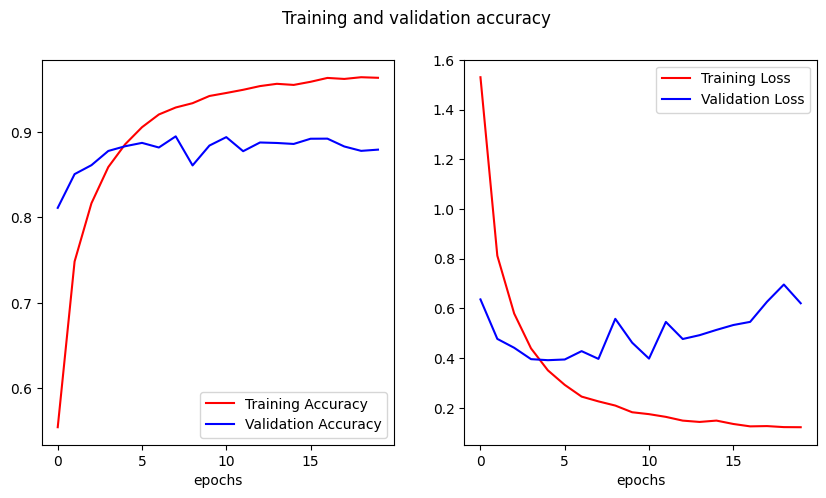

In [46]:
# Get training and validation accuracies
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Get number of epochs
epochs = range(len(acc))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Training and validation accuracy')

for i, (data, label) in enumerate(zip([(acc, val_acc), (loss, val_loss)], ["Accuracy", "Loss"])):
    ax[i].plot(epochs, data[0], 'r', label="Training " + label)
    ax[i].plot(epochs, data[1], 'b', label="Validation " + label)
    ax[i].legend()
    ax[i].set_xlabel('epochs')

plt.show()

In [48]:
model.save("plusnine.keras")

In [49]:
import pickle

# Example: Saving model training history
history_data = {
    "accuracy": [0.2750, 0.6329, 0.7466],  # Add your accuracy values
    "loss": [2.6899, 1.1745, 0.7880],     # Add your loss values
}

with open('model_history.pkl', 'wb') as file:
    pickle.dump(history_data, file)

print("Training history saved to mdl_history.pkl")


Training history saved to mdl_history.pkl


In [50]:
# Save the model architecture and weights using pickle
with open('cnn_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model saved to cnn_mdl.pkl")


Model saved to cnn_mdl.pkl


In [51]:
pip install joblib


[notice] A new release of pip is available: 23.2.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [62]:
def prepare_datasets():
    ### BEGIN CODE HERE ###
    # some code
    # Extract class names from the train dataset
    class_labels = {index: label for index, label in enumerate(train_dataset.class_names)}
    ### END CODE HERE ###
    
    return train_dataset, validation_dataset, class_labels


In [22]:
import numpy as np
from PIL import Image
from tensorflow.keras.models import load_model

# Load the CNN model
model = load_model('cnn_model.h5')  # Load the model using Keras' load_model

# Define the function
def get_class(image_url, class_labels):
    """
    Predict the class of an image using a trained CNN model.

    Args:
        image_url (str): Path or URL to the image.
        class_labels (list): List of class labels (for mapping output).

    Returns:
        str: Predicted class label.
    """
    try:
        # Load and preprocess the image
        image = Image.open(image_url).convert('RGB')  # Ensure it's RGB
        image = image.resize((256, 256))  # Resize to match the model's expected input size
        image_array = np.array(image) / 255.0  # Normalize pixel values (0 to 1)
        image_array = np.expand_dims(image_array, axis=0)  # Add batch dimension (1, 256, 256, 3)

        # Predict class
        prediction = model.predict(image_array)
        predicted_class = np.argmax(prediction)  # Get the index of the highest probability
        
        return f"Predicted class: {class_labels[predicted_class]}", prediction, predicted_class
    
    except Exception as e:
        return f"Error: {str(e)}", f"Error: {str(e)}", f"Error: {str(e)}"

# Example usage (assuming you have class labels)
# class_labels = ['class1', 'class2', 'class3', ...]  # Define your class labels list
# print(get_class('path_to_image.jpg', class_labels))

In [47]:
img_class,predictions,predicted_class=get_class("C:/Users/kinta/Downloads/Phyton/dataset/dataset/plant_dataset/valid/Corn_(maize)___Northern_Leaf_Blight/Corn_(maize)___Northern_Leaf_Blight_441.JPG",class_labels)
print(img_class)
print(predictions)
print(predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Predicted class: Potato___Late_blight
[[0.0263156  0.02630839 0.02633924 0.02631582 0.02633829 0.02629782
  0.02630614 0.02630462 0.02633148 0.02632325 0.02631824 0.02632454
  0.0263385  0.02630952 0.02628742 0.02631947 0.02628711 0.02634655
  0.0263058  0.02630661 0.02629261 0.02635046 0.02633626 0.02632632
  0.02630248 0.02629706 0.02632041 0.0263013  0.02634406 0.02631
  0.02632735 0.02630855 0.02630797 0.02630274 0.02630658 0.02631295
  0.02630377 0.02632463]]
21


In [42]:
print(class_labels)

{0: 'Apple___Apple_scab', 1: 'Apple___Black_rot', 2: 'Apple___Cedar_apple_rust', 3: 'Apple___healthy', 4: 'Blueberry___healthy', 5: 'Cherry_(including_sour)___Powdery_mildew', 6: 'Cherry_(including_sour)___healthy', 7: 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 8: 'Corn_(maize)___Common_rust_', 9: 'Corn_(maize)___Northern_Leaf_Blight', 10: 'Corn_(maize)___healthy', 11: 'Grape___Black_rot', 12: 'Grape___Esca_(Black_Measles)', 13: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 14: 'Grape___healthy', 15: 'Orange___Haunglongbing_(Citrus_greening)', 16: 'Peach___Bacterial_spot', 17: 'Peach___healthy', 18: 'Pepper,_bell___Bacterial_spot', 19: 'Pepper,_bell___healthy', 20: 'Potato___Early_blight', 21: 'Potato___Late_blight', 22: 'Potato___healthy', 23: 'Raspberry___healthy', 24: 'Soybean___healthy', 25: 'Squash___Powdery_mildew', 26: 'Strawberry___Leaf_scorch', 27: 'Strawberry___healthy', 28: 'Tomato___Bacterial_spot', 29: 'Tomato___Early_blight', 30: 'Tomato___Late_blight', 31: 'To